This tutorial demonstrates that the distribution of relaxation times (DRT) can be deconvolved using other norms to analyze artificial impedance data. More details can be found in the article entitled 'Beyond Ridge Regression: Enhancing Distribution of Relaxation Times Deconvolution' (DOI: 10.1149/1945-7111/ad576a).

In [1]:
# importing various package
import numpy as np
from math import log10, pi, sin, cos, log
from numpy.linalg import norm
from scipy.linalg import null_space
import matplotlib.pyplot as plt
import time
import compute_DRT
import importlib
from cvxopt import matrix, solvers
from scipy.optimize import minimize
from bayes_opt import BayesianOptimization
import cvxpy as cp

In [2]:
# options for the plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=15)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)

# 1. Generate artificial Impedance Data using the 1xZARC Model

## 1.1 Define the exact and experimental Impedances

In [3]:
# define frequency range
N_freqs = 81
freq_min = 10**-2
freq_max = 10**6
freq_vec = np.logspace(log10(freq_min), log10(freq_max), num=N_freqs, endpoint=True)

# parameters for the single ZARC model
R_inf = 20
R_ct_1 = 50
R_ct_2 = 10
phi_1 = 0.8
phi_2 = 0.8
tau_1 = 0.1
tau_2 = 10**(-4)
Z_exact = R_inf+R_ct_1/(1.0+(1j*2.*pi*freq_vec*tau_1)**phi_1)+R_ct_2/(1.0+(1j*2.*pi*freq_vec*tau_2)**phi_2)

# synthetic error
rng = np.random.seed(1225)
sigma_n_exp = 0.2

# artificial impedance data
Z_exp = Z_exact + sigma_n_exp*(np.random.normal(0, 1, N_freqs)+1j*np.random.normal(0, 1, N_freqs))

## 1.2 Nyquist Plots of the experimental and exact Impedances

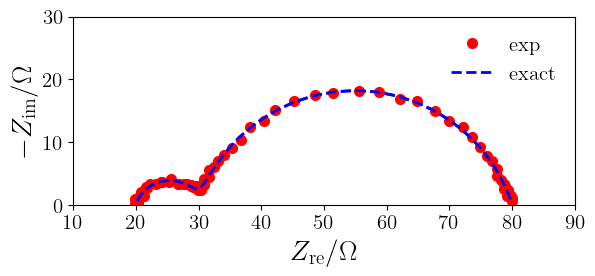

In [4]:
fig, ax = plt.subplots()
plt.plot(np.real(Z_exact), -np.imag(Z_exact), '--', linewidth=2, color='blue')
plt.plot(np.real(Z_exp), -np.imag(Z_exp), 'o', markersize=7, color='red', label='exp')
plt.plot(np.real(Z_exact), -np.imag(Z_exact), '--', linewidth=2, color='blue', label='exact')
plt.legend(frameon=False, fontsize = 15)
plt.axis('scaled')
plt.xlim(10, 90)
plt.xticks(np.arange(10, 90.1, 10))
plt.ylim(0, 30)
plt.yticks(np.arange(0, 30.1, 10))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(r'$Z_{\rm re}/\Omega$', fontsize = 20)
plt.ylabel(r'$-Z_{\rm im}/\Omega$', fontsize = 20)
fig.set_size_inches(6.472, 4)
plt.show()

## 1.3 Define the exact DRT

In [5]:
N_tau = 81
tau_vec = np.logspace(-log10(freq_max), -log10(freq_min), num=N_tau, endpoint=True)
log_tau_vec = np.log(tau_vec)
gamma_1 = (R_ct_1)/(2.*pi)*sin((1.-phi_1)*pi)/(np.cosh(phi_1*np.log(tau_vec/(tau_1)))-cos((1.-phi_1)*pi))
gamma_2 = (R_ct_2)/(2.*pi)*sin((1.-phi_2)*pi)/(np.cosh(phi_2*np.log(tau_vec/(tau_2)))-cos((1.-phi_2)*pi))
gamma_exact = gamma_1 + gamma_2

# 2. Compute the DRT through Ridge Regression (RR)

## 2.1 Compute the Matrices for quadratic Programming with $\lambda=10^{-3}$

In [6]:
importlib.reload(compute_DRT)

lambda_0 = 1E-3

# data
Z_re = Z_exp.real
Z_im = Z_exp.imag
Z_RR = np.zeros(2*N_freqs)
Z_RR[:N_freqs] = Z_exp.real.flatten()
Z_RR[N_freqs:] = Z_exp.imag.flatten()

# compute matrix A
A_complex = compute_DRT.compute_A_complex(freq_vec, log_tau_vec)
A_re = np.real(A_complex)
A_im = np.imag(A_complex)

A_R0 = np.zeros((2*N_freqs,1))
A_R0[0:N_freqs,0] = 1.0
A = np.hstack( ( A_R0, np.vstack((A_re, A_im)) ) )

# compute matrix L
L2_standard = compute_DRT.compute_L2(log_tau_vec)
L2 = np.hstack( ( np.zeros((N_tau-2, 1)), L2_standard ) )

# solve 1/2 x.T@(Q@x) + p@x
Q = A.T@A + lambda_0*L2.T@L2 
p = -A.T@Z_RR

# G@x<=0
G = -np.identity(N_tau+1)
h = np.zeros(N_tau+1)

# Define and solve the CVXopt
# to be defined below: 
Q_cvxopt = matrix(Q)
p_cvxopt = matrix(p)
G_cvxopt = matrix(G)
h_cvxopt = matrix(h)

## 2.2 Deconvolve the DRT

In [7]:
sol = solvers.qp(Q_cvxopt, p_cvxopt, G_cvxopt, h_cvxopt)
x = np.array(sol['x']).flatten()
gamma_hat = x[1:]

     pcost       dcost       gap    pres   dres
 0: -8.8377e+04 -9.1698e+04  5e+03  1e+01  3e-02
 1: -8.8478e+04 -8.9168e+04  7e+02  1e+00  4e-03
 2: -8.8548e+04 -8.8649e+04  1e+02  9e-02  3e-04
 3: -8.8561e+04 -8.8574e+04  1e+01  3e-03  1e-05
 4: -8.8562e+04 -8.8564e+04  1e+00  2e-04  8e-07
 5: -8.8562e+04 -8.8563e+04  1e-01  3e-06  1e-08
 6: -8.8562e+04 -8.8562e+04  2e-02  3e-07  9e-10
 7: -8.8562e+04 -8.8562e+04  1e-03  2e-08  6e-11
Optimal solution found.


## 2.3 Compare the DRT obtained with RR against the exact DRT

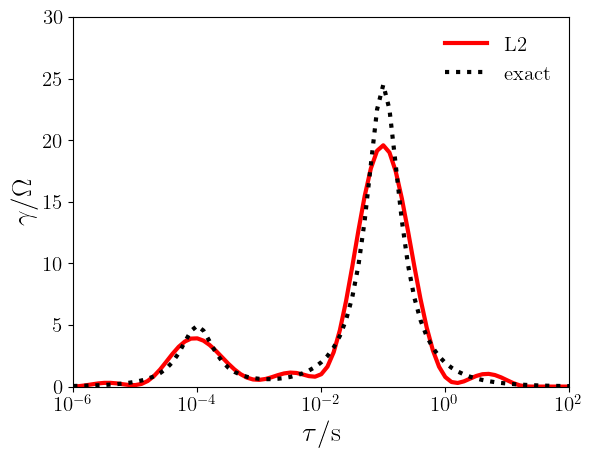

In [8]:
plt.semilogx(tau_vec, gamma_hat, '-', linewidth=3, color='red', label='L2')
plt.semilogx(tau_vec, gamma_exact, ':', linewidth=3, color='black', label='exact')
plt.xlabel('$\\tau/\\rm s$', fontsize = 20)
plt.ylabel('$\\gamma/\\Omega$', fontsize = 20)
plt.legend(frameon=False, fontsize = 15, loc='upper right')
plt.xlim(np.min(tau_vec), np.max(tau_vec))
plt.ylim([0, 30])
plt.yticks(np.arange(0, 30.1, step=5))
fig.set_size_inches(6.472, 4)
plt.show()

# 3. DRT Deconvolution with different Norms

To implement these optimization problems in Python using linear programming, we can use libraries like `cvxpy`, which is designed for convex optimization. Linear programming typically involves linear objective functions and constraints, but we can handle the  $\ell_1$ and $\ell_\infty$ norms by introducing auxiliary variables and additional constraints.

Let's outline the implementation for each problem:

### Minimizing $\ell_\infty$ norm of $Ax - b$ with $\ell_1$ regularization of $Lx$

This problem can be formulated as:
$$
\begin{align*}
\min_{x, t} \ & t + \lambda \|Lx\|_1 \\
\text{s.t.} \ & -t \mathbf{1} \leq Ax - b \leq t \mathbf{1}
\end{align*}
$$
where $t$ is an auxiliary variable representing the $\ell_\infty$ norm of $Ax - b$, and $\mathbf{1}$ is a vector of ones.

### Minimizing $\ell_\infty$ norm of $Ax - b$ with $\ell_\infty$ regularization of $Lx$

This problem can be formulated as:
$$
\begin{align*}
\min_{x, t, u} \ & t + \lambda u \\
\text{s.t.} \ & -t \mathbf{1} \leq Ax - b \leq t \mathbf{1} \\
              & -u \mathbf{1} \leq Lx \leq u \mathbf{1}
\end{align*}
$$
where $u$ is an auxiliary variable representing the $\ell_\infty$ norm of $Lx$.

### Minimizing $\ell_1$ norm of $Ax - b$ with $\ell_\infty$ regularization of $Lx$

This problem can be formulated as:
$$
\begin{align*}
\min_{x, u} \ & \|Ax - b\|_1 + \lambda u \\
\text{s.t.} \ & -u \mathbf{1} \leq Lx \leq u \mathbf{1}
\end{align*}
$$

### Minimizing $\ell_1$ norm of $Ax - b$ with $\ell_1$ regularization of $Lx$

This problem can be formulated as:
$$
\min_x \ \|Ax - b\|_1 + \lambda \|Lx\|_1
$$

## 3.1 Define the required Matrices and Vectors

In [9]:
importlib.reload(compute_DRT)

L1 = compute_DRT.compute_L1(log_tau_vec) # first-order differentiation matrix
L1 = np.hstack( ( np.zeros((N_tau-1, 1)), L1 ) )

L3 = compute_DRT.compute_L3(log_tau_vec) # third-order differentiation matrix
L3 = np.hstack( ( np.zeros((N_tau-3, 1)), L3 ) )

b = np.copy(Z_RR)    # Replace with your b vector
L = np.copy(L3)   # Replace with your L matrix
lambda_0 = 1E-5       # Regularization parameter

## 3.2 Define the Functions

In [10]:
import cvxpy as cp

def prob_inf_1(lambda_reg, A, L, b):
    # Define the optimization variable
    x = cp.Variable(A.shape[1], nonneg=True)

    # Define the objective function: minimize ||Ax - b||_inf + lambda * ||Lx||_1
    objective = cp.Minimize(cp.norm_inf(A @ x - b) + lambda_reg * cp.norm1(L @ x))

    # Set up and solve the problem without additional constraints
    prob = cp.Problem(objective)
    prob.solve(solver=cp.GUROBI)
    
    # Return the optimized value of x
    return x.value


def prob_inf_inf(lambda_reg, A, L, b):
    # Define the optimization variable
    x = cp.Variable(A.shape[1], nonneg=True)

    # Define the objective function: minimize ||Ax - b||_inf + lambda * ||Lx||_inf
    objective = cp.Minimize(cp.norm_inf(A @ x - b) + lambda_reg * cp.norm_inf(L @ x))

    # Set up and solve the problem without additional constraints
    prob = cp.Problem(objective)
    prob.solve(solver=cp.GUROBI)
    
    # Return the optimized value of x
    return x.value


def prob_1_inf(lambda_reg, A, L, b):
    # Define the optimization variable
    x = cp.Variable(A.shape[1], nonneg=True)

    # Define the objective function: minimize ||Ax - b||_1 + lambda * ||Lx||_inf
    objective = cp.Minimize(cp.norm1(A @ x - b) + lambda_reg * cp.norm_inf(L @ x))

    # Set up and solve the problem without additional constraints
    prob = cp.Problem(objective)
    prob.solve(solver=cp.GUROBI)
    
    # Return the optimized value of x
    return x.value


def prob_1_1(lambda_reg, A, L, b):
    # Define the optimization variable
    x = cp.Variable(A.shape[1], nonneg=True)

    # Define the objective function: minimize ||Ax - b||_1 + lambda * ||Lx||_1
    objective = cp.Minimize(cp.norm1(A @ x - b) + lambda_reg * cp.norm1(L @ x))

    # Set up and solve the problem without additional constraints
    prob = cp.Problem(objective)
    prob.solve(solver=cp.GUROBI)
    
    # Return the optimized value of x
    return x.value

def prob_RR(lambda_reg, A, L, b):

    # solve 1/2 x.T@(Q@x) + p@x
    Q = A.T@A + lambda_reg*L.T@L 
    p = -A.T@b

    # N_tau's
    N_tau = A.shape[1]-1

    # G@x<=0
    G = -np.identity(N_tau+1)
    h = np.zeros(N_tau+1)

    # Define and solve the CVXopt
    # to be defined below: 
    Q_cvxopt = matrix(Q)
    p_cvxopt = matrix(p)
    G_cvxopt = matrix(G)
    h_cvxopt = matrix(h)

    # solution
    sol = solvers.qp(Q_cvxopt, p_cvxopt, G_cvxopt, h_cvxopt)
    x = np.array(sol['x']).flatten()

    return x

# Define the objective function
def objective(log10_lambda_0, problem_func, A, L, b, gamma_exact):

    lambda_reg = 10**log10_lambda_0  # Convert log_lambda_0 to lambda_reg
    x = problem_func(lambda_reg, A, L, b)
    norm_diff = -np.linalg.norm(gamma_exact - x[1:], 2)  # Calculate the norm difference
    return norm_diff  # Minimize the negative norm difference

# Define the parameter range for log_lambda_0
pbounds = {'log10_lambda_0': (-6, 2)}

## 3.3 Deconvolve the DRT using each Norm and for various different Values of the Regularization Parameter

In [11]:
lambda_reg_vec = np.logspace(-6, 2, 101)

norm_diff_inf_1 = np.zeros_like(lambda_reg_vec)
norm_diff_inf_inf = np.zeros_like(lambda_reg_vec)
norm_diff_1_inf = np.zeros_like(lambda_reg_vec)
norm_diff_1_1 = np.zeros_like(lambda_reg_vec)
norm_diff_RR = np.zeros_like(lambda_reg_vec)


for iter, lambda_reg in enumerate(lambda_reg_vec):

    # print(lambda_reg)
    x_inf_1 = prob_inf_1(lambda_reg, A, L, b)
    x_inf_inf = prob_inf_inf(lambda_reg, A, L, b)
    x_1_inf = prob_1_inf(lambda_reg, A, L, b)
    x_1_1 = prob_1_1(lambda_reg, A, L, b)
    x_RR = prob_RR(lambda_reg, A, L2, b)

    norm_diff_inf_1[iter] = np.linalg.norm(x_inf_1[1:]-gamma_exact, 2)
    norm_diff_inf_inf[iter] = np.linalg.norm(x_inf_inf[1:]-gamma_exact, 2)
    norm_diff_1_inf[iter] = np.linalg.norm(x_1_inf[1:]-gamma_exact, 2)
    norm_diff_1_1[iter] = np.linalg.norm(x_1_1[1:]-gamma_exact, 2)
    norm_diff_RR[iter] = np.linalg.norm(x_RR[1:]-gamma_exact, 2)

Restricted license - for non-production use only - expires 2025-11-24
     pcost       dcost       gap    pres   dres
 0: -8.8377e+04 -9.1696e+04  5e+03  1e+01  3e-02
 1: -8.8479e+04 -8.9189e+04  8e+02  1e+00  4e-03
 2: -8.8550e+04 -8.8665e+04  1e+02  8e-15  1e-16
 3: -8.8563e+04 -8.8578e+04  2e+01  1e-14  1e-16
 4: -8.8564e+04 -8.8566e+04  2e+00  1e-14  1e-16
 5: -8.8564e+04 -8.8565e+04  3e-01  1e-14  1e-16
 6: -8.8564e+04 -8.8564e+04  7e-02  9e-15  1e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -8.8377e+04 -9.1696e+04  5e+03  1e+01  3e-02
 1: -8.8479e+04 -8.9189e+04  8e+02  1e+00  4e-03
 2: -8.8550e+04 -8.8664e+04  1e+02  8e-15  1e-16
 3: -8.8563e+04 -8.8578e+04  2e+01  1e-14  1e-16
 4: -8.8564e+04 -8.8566e+04  2e+00  8e-15  1e-16
 5: -8.8564e+04 -8.8565e+04  3e-01  1e-14  1e-16
 6: -8.8564e+04 -8.8564e+04  7e-02  1e-14  1e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -8.8377e+04 -9.1696e+04  5e+03  1e+01  3e-02
 1:

# 4. Deconvolve the DRTs

## 4.1 Recover the optimal DRT using the $\infty$- and 1-norm

In [12]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_inf_1, A, L, b, gamma_exact),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_inf_1 = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -13.85    | -2.664    |
| 2         | -41.49    | -0.2374   |
| 3         | -45.56    | 0.002363  |
| 4         | -6.675    | -4.073    |
| 5         | -19.14    | -5.999    |
| 6         | -7.9      | -4.826    |
| 7         | -7.26     | -3.574    |
| 8         | -6.667    | -4.421    |
| 9         | -6.676    | -4.255    |
| 10        | -6.997    | -3.853    |
| 11        | -6.973    | -4.536    |
| 12        | -48.62    | 1.997     |
| 13        | -6.68     | -4.349    |
| 14        | -9.597    | -3.275    |
| 15        | -25.42    | -1.755    |
| 16        | -12.19    | -5.242    |
| 17        | -6.674    | -4.153    |
| 18        | -6.713    | -4.379    |
| 19        | -6.674    | -4.125    |
| 20        | -6.674    | -4.198    |
| 21        | -6.632    | -4.039    |
| 22        | -6.727    | -3.996    |
| 23        | -6.675    | -4.067    |
| 24        | -6.675    | -4.065    |
| 25        

## 4.2 Recover the optimal DRT using the $\infty$-norm

In [13]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_inf_inf, A, L, b, gamma_exact),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_inf_inf = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -10.54    | -2.664    |
| 2         | -25.26    | -0.2374   |
| 3         | -28.26    | 0.002363  |
| 4         | -12.14    | -1.821    |
| 5         | -18.63    | -4.629    |
| 6         | -36.06    | -5.999    |
| 7         | -9.841    | -3.565    |
| 8         | -9.286    | -3.169    |
| 9         | -9.681    | -3.321    |
| 10        | -48.62    | 2.0       |
| 11        | -13.22    | -3.952    |
| 12        | -13.7     | -1.25     |
| 13        | -9.719    | -2.947    |
| 14        | -10.85    | -2.257    |
| 15        | -9.392    | -3.093    |
| 16        | -9.286    | -3.181    |
| 17        | -9.506    | -3.161    |
| 18        | -13.12    | -1.55     |
| 19        | -10.87    | -2.46     |
| 20        | -9.841    | -3.565    |
| 21        | -16.41    | -0.8981   |
| 22        | -40.88    | 0.96      |
| 23        | -13.55    | -4.242    |
| 24        | -20.68    | -5.219    |
| 25        

## 4.3 Recover the optimal DRT using the 1- and $\infty$-norm

In [14]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_1_inf, A, L, b, gamma_exact),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_1_inf = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -11.1     | -2.664    |
| 2         | -12.43    | -0.2374   |
| 3         | -12.88    | 0.002363  |
| 4         | -9.905    | -2.158    |
| 5         | -9.762    | -1.533    |
| 6         | -66.47    | -5.999    |
| 7         | -28.81    | 1.998     |
| 8         | -10.62    | -1.113    |
| 9         | -10.07    | -1.827    |
| 10        | -9.781    | -2.364    |
| 11        | -9.619    | -1.406    |
| 12        | -9.644    | -1.365    |
| 13        | -9.621    | -1.42     |
| 14        | -9.621    | -1.416    |
| 15        | -9.619    | -1.414    |
| 16        | -9.621    | -1.413    |
| 17        | -9.621    | -1.409    |
| 18        | -9.621    | -1.408    |
| 19        | -9.644    | -1.397    |
| 20        | -9.619    | -1.423    |
| 21        | -9.619    | -1.423    |
| 22        | -9.619    | -1.421    |
| 23        | -9.621    | -1.422    |
| 24        | -9.619    | -1.42     |
| 25        

## 4.4 Recover the optimal DRT using the 1-norm

In [15]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_1_1, A, L, b, gamma_exact),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_1_1 = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
| 1         | -7.264    | -2.664    |
| 2         | -18.53    | -0.2374   |
| 3         | -21.94    | 0.002363  |
| 4         | -7.98     | -2.097    |
| 5         | -9.267    | -3.857    |
| 6         | -29.91    | -5.436    |
| 7         | -54.79    | 1.998     |
| 8         | -7.93     | -3.264    |
| 9         | -10.05    | -1.423    |
| 10        | -7.311    | -2.452    |
| 11        | -7.422    | -2.85     |
| 12        | -7.038    | -2.578    |
| 13        | -13.12    | -4.413    |
| 14        | -9.171    | -1.776    |
| 15        | -13.78    | -0.9409   |
| 16        | -7.705    | -3.056    |
| 17        | -8.604    | -3.547    |
| 18        | -6.917    | -2.546    |
| 19        | -59.51    | -6.0      |
| 20        | -16.15    | -4.867    |
| 21        | -6.873    | -2.525    |
| 22        | -35.13    | 0.8319    |
| 23        | -11.42    | -4.092    |
| 24        | -8.043    | -1.964    |
| 25        

## 4.5 Recover the optimal DRT using the 2-norm (RR)

In [16]:
# Instantiate Bayesian Optimization
optimizer = BayesianOptimization(
    f=lambda log10_lambda_0: objective(log10_lambda_0, prob_RR, A, L2, b, gamma_exact),
    pbounds=pbounds,
    random_state=1,
)

# Perform optimization
optimizer.maximize(
    init_points=2,
    n_iter=30,
)

# Best log_lambda_0 value
optimal_log10_lambda_0 = optimizer.max['params']['log10_lambda_0']
optimal_lambda_RR = 10**optimal_log10_lambda_0

|   iter    |  target   | log10_... |
-------------------------------------
     pcost       dcost       gap    pres   dres
 0: -8.8377e+04 -9.1699e+04  5e+03  1e+01  3e-02
 1: -8.8478e+04 -8.9152e+04  7e+02  1e+00  4e-03
 2: -8.8546e+04 -8.8644e+04  1e+02  9e-02  3e-04
 3: -8.8560e+04 -8.8571e+04  1e+01  3e-03  9e-06
 4: -8.8561e+04 -8.8562e+04  1e+00  2e-04  6e-07
 5: -8.8561e+04 -8.8561e+04  1e-01  9e-07  3e-09
 6: -8.8561e+04 -8.8561e+04  1e-02  7e-08  2e-10
Optimal solution found.
| 1         | -11.25    | -2.664    |
     pcost       dcost       gap    pres   dres
 0: -8.8296e+04 -9.1670e+04  5e+03  1e+01  3e-02
 1: -8.8340e+04 -8.8805e+04  5e+02  5e-01  1e-03
 2: -8.8396e+04 -8.8446e+04  5e+01  4e-02  1e-04
 3: -8.8408e+04 -8.8414e+04  7e+00  3e-03  9e-06
 4: -8.8409e+04 -8.8410e+04  1e+00  7e-06  2e-08
 5: -8.8409e+04 -8.8410e+04  1e-01  9e-07  3e-09
 6: -8.8409e+04 -8.8409e+04  2e-02  8e-15  1e-15
Optimal solution found.
| 2         | -23.03    | -0.2374   |
     pcost       d

## 4.6 Plot the DRT Residual for different Values of the Regularization Parameter

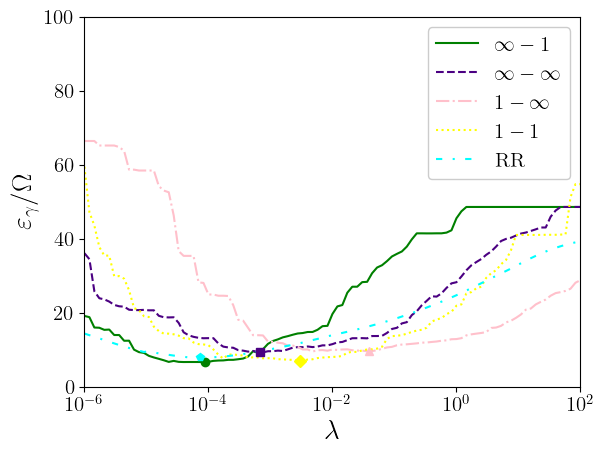

In [17]:
# Define colorblind-friendly colors for each line and marker
color_inf_1 = 'green'
color_inf_inf = 'indigo'
color_1_inf = 'pink'
color_1_1 = 'yellow'
color_RR = 'cyan'

# Modify line styles for better differentiation
line_style_inf_1 = '-'
line_style_inf_inf = '--'
line_style_1_inf = '-.'
line_style_1_1 = ':'
line_style_RR = (0, (3, 5, 1, 5))  # Custom dash pattern

# Modify marker styles for optimal lambda values
marker_inf_1 = 'o'
marker_inf_inf = 's'  # Square
marker_1_inf = '^'    # Triangle
marker_1_1 = 'D'      # Diamond
marker_RR = 'p'       # Pentagon

# Plotting the lines with colorblind-friendly colors, line styles, and markers
plt.semilogx(lambda_reg_vec, norm_diff_inf_1, label=r'$\infty-1$', color=color_inf_1, linestyle=line_style_inf_1)
plt.semilogx(lambda_reg_vec, norm_diff_inf_inf, label=r'$\infty-\infty$', color=color_inf_inf, linestyle=line_style_inf_inf)
plt.semilogx(lambda_reg_vec, norm_diff_1_inf, label=r'$1-\infty$', color=color_1_inf, linestyle=line_style_1_inf)
plt.semilogx(lambda_reg_vec, norm_diff_1_1, label=r'$1-1$', color=color_1_1, linestyle=line_style_1_1)
plt.semilogx(lambda_reg_vec, norm_diff_RR, label=r'$\rm RR$', color=color_RR, linestyle=line_style_RR)

# Adding markers for optimal lambda values with corresponding colors
plt.semilogx(optimal_lambda_inf_1, np.min(norm_diff_inf_1), marker=marker_inf_1, color=color_inf_1)
plt.semilogx(optimal_lambda_inf_inf, np.min(norm_diff_inf_inf), marker=marker_inf_inf, color=color_inf_inf)
plt.semilogx(optimal_lambda_1_inf, np.min(norm_diff_1_inf), marker=marker_1_inf, color=color_1_inf)
plt.semilogx(optimal_lambda_1_1, np.min(norm_diff_1_1), marker=marker_1_1, color=color_1_1)
plt.semilogx(optimal_lambda_RR, np.min(norm_diff_RR), marker=marker_RR, color=color_RR)

# Other plot settings (unchanged)
plt.legend(frameon=True, loc='upper right', fontsize=15, framealpha=1.0)
plt.xlim(10**(-6), 10**2)
plt.ylim(0, 100)
plt.xscale('log')
plt.xticks([10**-6, 10**-4, 10**-2, 1, 10**2], [r'$10^{-6}$', r'$10^{-4}$', r'$10^{-2}$', r'$10^{0}$', r'$10^{2}$'])
plt.xlabel(r'$\lambda$', fontsize=20)
plt.ylabel(r'$\varepsilon_{\gamma}/\Omega$', fontsize=20)
fig.set_size_inches(6.472, 4)
plt.show()

## 4.7 Compute the optimized DRTs and Impedances

In [18]:
# optimized DRTs
x_inf_1 = prob_inf_1(optimal_lambda_inf_1, A, L, b)
x_inf_inf = prob_inf_inf(optimal_lambda_inf_inf, A, L, b)
x_1_inf = prob_1_inf(optimal_lambda_1_inf, A, L, b)
x_1_1 = prob_1_1(optimal_lambda_1_1, A, L, b)
x_RR = prob_RR(optimal_lambda_RR, A, L2, b)

# recovered impedances
Z_inf_1_mat_FC = np.dot(A, x_inf_1)
Z_inf_1_mat_FC = Z_inf_1_mat_FC[:N_freqs] + 1j*Z_inf_1_mat_FC[N_freqs:]
Z_inf_inf_mat_FC = np.dot(A, x_inf_inf)
Z_inf_inf_mat_FC = Z_inf_inf_mat_FC[:N_freqs] + 1j*Z_inf_inf_mat_FC[N_freqs:]
Z_1_inf_mat_FC = np.dot(A, x_1_inf)
Z_1_inf_mat_FC = Z_1_inf_mat_FC[:N_freqs] + 1j*Z_1_inf_mat_FC[N_freqs:]
Z_1_1_mat_FC = np.dot(A, x_1_1)
Z_1_1_mat_FC = Z_1_1_mat_FC[:N_freqs] + 1j*Z_1_1_mat_FC[N_freqs:]
Z_RR_mat_FC = np.dot(A, x_RR)
Z_RR_mat_FC = Z_RR_mat_FC[:N_freqs] + 1j*Z_RR_mat_FC[N_freqs:]

     pcost       dcost       gap    pres   dres
 0: -8.8377e+04 -9.1696e+04  5e+03  1e+01  3e-02
 1: -8.8479e+04 -8.9187e+04  8e+02  1e+00  4e-03
 2: -8.8550e+04 -8.8655e+04  1e+02  6e-02  2e-04
 3: -8.8563e+04 -8.8578e+04  2e+01  2e-03  6e-06
 4: -8.8564e+04 -8.8566e+04  2e+00  2e-04  6e-07
 5: -8.8564e+04 -8.8564e+04  4e-01  2e-05  8e-08
 6: -8.8564e+04 -8.8564e+04  7e-02  3e-06  1e-08
 7: -8.8564e+04 -8.8564e+04  1e-02  2e-07  8e-10
 8: -8.8564e+04 -8.8564e+04  5e-04  6e-09  2e-11
Optimal solution found.


# 5. Comparison

## 5.1 Compute the DRT and Impedance Residuals

In [19]:
L1 = compute_DRT.compute_L1(log_tau_vec)
# DRT residuals
print('DRT error for the inf- and 1-norm', np.linalg.norm(x_inf_1[1:]-gamma_exact) + np.linalg.norm(np.dot(L1, x_inf_1[1:]-gamma_exact)))
print('DRT error for the inf-norm', np.linalg.norm(x_inf_inf[1:]-gamma_exact) + np.linalg.norm(np.dot(L1, x_inf_inf[1:]-gamma_exact)))
print('DRT error for the 1- and inf-norm', np.linalg.norm(x_1_inf[1:]-gamma_exact) + np.linalg.norm(np.dot(L1, x_1_inf[1:]-gamma_exact)))
print('DRT error for the 1-norm', np.linalg.norm(x_1_1[1:]-gamma_exact) + np.linalg.norm(np.dot(L1, x_1_1[1:]-gamma_exact)))
print('DRT error for the RR', np.linalg.norm(x_RR[1:]-gamma_exact) + np.linalg.norm(np.dot(L1, x_RR[1:]-gamma_exact)))
print('----------')

# impedance residuals
print('Impedance error for the inf- and 1-norm', np.linalg.norm(Z_inf_1_mat_FC-Z_exact))
print('Impedance error for the inf-norm', np.linalg.norm(Z_inf_inf_mat_FC-Z_exact))
print('Impedance error for the 1- and inf-norm', np.linalg.norm(Z_1_inf_mat_FC-Z_exact))
print('Impedance error for the 1-norm', np.linalg.norm(Z_1_1_mat_FC-Z_exact))
print('Impedance error for the RR', np.linalg.norm(Z_RR_mat_FC-Z_exact))

DRT error for the inf- and 1-norm 28.600966641671118
DRT error for the inf-norm 38.50209897542912
DRT error for the 1- and inf-norm 39.17236621135146
DRT error for the 1-norm 29.228671349382605
DRT error for the RR 32.460706936359806
----------
Impedance error for the inf- and 1-norm 0.9711024414566001
Impedance error for the inf-norm 1.136277838176016
Impedance error for the 1- and inf-norm 1.0603518892115067
Impedance error for the 1-norm 0.9392093448102292
Impedance error for the RR 0.8154565913255574


## 5.2 Compare the recovered DRTs to the exact DRT

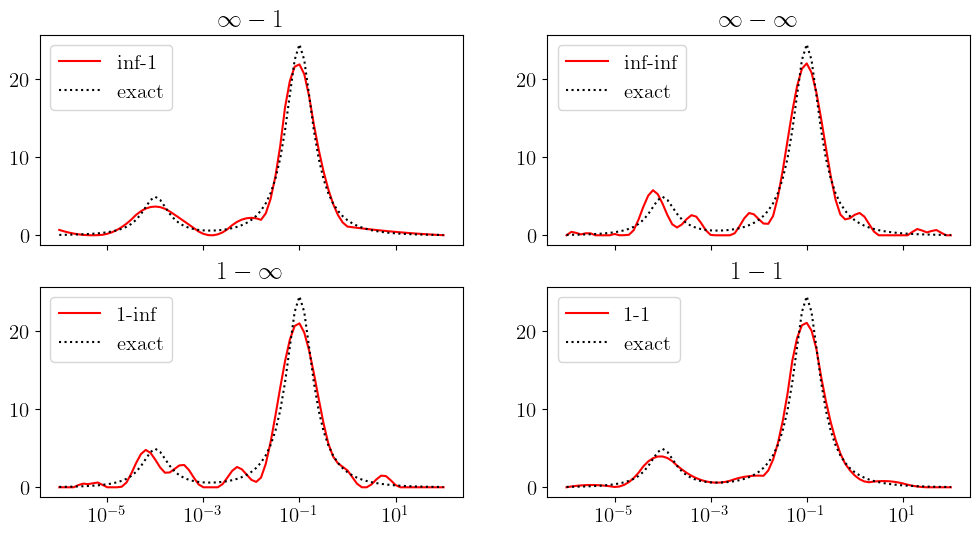

In [20]:
fig, ((ax11, ax12), (ax21, ax22)) = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=(12, 6))

ax11.set_title(r'$\infty-1$')
ax11.semilogx(tau_vec, x_inf_1[1:], '-', color='red', label='inf-1')
ax11.semilogx(tau_vec, gamma_exact, ':', color='black', label='exact')
ax11.legend(loc="upper left")

ax12.set_title(r'$\infty-\infty$')
ax12.semilogx(tau_vec, x_inf_inf[1:], '-', color='red', label='inf-inf')
ax12.semilogx(tau_vec, gamma_exact, ':', color='black', label='exact')
ax12.legend(loc="upper left")

ax21.set_title(r'$1-\infty$')
ax21.semilogx(tau_vec, x_1_inf[1:], '-', color='red', label='1-inf')
ax21.semilogx(tau_vec, gamma_exact, ':', color='black', label='exact')
ax21.legend(loc="upper left")

ax22.set_title(r'$1-1$')
ax22.semilogx(tau_vec, x_1_1[1:], '-', color='red', label='1-1')
ax22.semilogx(tau_vec, gamma_exact, ':', color='black', label='exact')
ax22.legend(loc="upper left")
plt.show()